In [1]:
# === Cell 0: Nested CV helper (DataFrame-aware) ===
from dataclasses import dataclass
from typing import Dict, Iterable, List, Optional, Union

import numpy as np
import pandas as pd

from sklearn.base import BaseEstimator, clone
from sklearn.model_selection import KFold, GridSearchCV, RandomizedSearchCV
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

@dataclass
class NestedCVResult:
    fold_results: pd.DataFrame
    summary: pd.DataFrame
    inner_cv_name: str
    outer_cv_name: str

def _mk_scorers(scoring: Optional[Union[str, Iterable[str], Dict[str, str]]] = None) -> Dict[str, str]:
    if scoring is None:
        return {
            "r2": "r2",
            "neg_mae": "neg_mean_absolute_error",
            "neg_rmse": "neg_root_mean_squared_error",
        }
    if isinstance(scoring, str):
        return {scoring: scoring}
    if isinstance(scoring, dict):
        return scoring
    return {s: s for s in scoring}

def _split_by_index(X, y, idx):
    """Return X[idx], y[idx] preserving pandas types when available."""
    if hasattr(X, "iloc"):
        X_part = X.iloc[idx]
    else:
        X_part = np.asarray(X)[idx]
    if hasattr(y, "iloc"):
        y_part = y.iloc[idx]
    else:
        y_part = np.asarray(y)[idx]
    return X_part, y_part

def nested_cv_evaluate(
    estimator: BaseEstimator,
    param_search: Dict[str, Iterable] | List[Dict[str, Iterable]],
    X,
    y,
    *,
    inner_cv=None,
    outer_cv=None,
    groups: Optional[Iterable] = None,
    search: str = "grid",
    n_iter: int = 50,
    scoring: Optional[Union[str, Iterable[str], Dict[str, str]]] = None,
    refit: str = "r2",
    n_jobs: int = -1,
    verbose: int = 0,
    random_state: Optional[int] = 42,
    return_train_score: bool = False,
    error_score: Union[str, float] = "raise",   # useful for debugging
) -> NestedCVResult:
    """Nested CV with inner tuning and outer test evaluation (DataFrame-safe)."""
    scorers = _mk_scorers(scoring)
    if inner_cv is None:
        inner_cv = KFold(n_splits=5, shuffle=True, random_state=random_state)
    if outer_cv is None:
        outer_cv = KFold(n_splits=5, shuffle=True, random_state=random_state)

    if search not in {"grid", "random"}:
        raise ValueError("search must be 'grid' or 'random'")

    if search == "grid":
        SearchCV = GridSearchCV
        search_kwargs = dict(param_grid=param_search)
    else:
        SearchCV = RandomizedSearchCV
        search_kwargs = dict(param_distributions=param_search, n_iter=n_iter, random_state=random_state)

    fold_rows = []

    # Prepare groups if provided
    g_array = None
    if groups is not None:
        g_array = np.asarray(groups)

    for fold_idx, (tr_idx, te_idx) in enumerate(outer_cv.split(X, y, g_array), start=1):
        X_tr, y_tr = _split_by_index(X, y, tr_idx)
        X_te, y_te = _split_by_index(X, y, te_idx)
        g_tr = g_array[tr_idx] if g_array is not None else None

        est = clone(estimator)
        searcher = SearchCV(
            estimator=est,
            cv=inner_cv,
            scoring=scorers,
            refit=refit,
            n_jobs=n_jobs,
            verbose=verbose,
            return_train_score=return_train_score,
            error_score=error_score,
            **search_kwargs,
        )
        if g_tr is None:
            searcher.fit(X_tr, y_tr)
        else:
            searcher.fit(X_tr, y_tr, groups=g_tr)

        best_model = searcher.best_estimator_
        y_pred = best_model.predict(X_te)

        row = {
            "fold": fold_idx,
            "best_params": searcher.best_params_,
            "r2_test": r2_score(y_te, y_pred),
            "mae_test": mean_absolute_error(y_te, y_pred),
            "rmse_test": mean_squared_error(y_te, y_pred, squared=False),
            "best_inner_score": searcher.best_score_,
        }
        fold_rows.append(row)

    fold_df = pd.DataFrame(fold_rows)

    def _agg(col):
        return pd.Series({"mean": float(np.mean(col)), "std": float(np.std(col))})

    summary = pd.concat(
        [
            fold_df["r2_test"].pipe(_agg).rename("r2_test"),
            fold_df["mae_test"].pipe(_agg).rename("mae_test"),
            fold_df["rmse_test"].pipe(_agg).rename("rmse_test"),
        ],
        axis=1,
    ).T

    return NestedCVResult(
        fold_results=fold_df,
        summary=summary,
        inner_cv_name=inner_cv.__class__.__name__,
        outer_cv_name=outer_cv.__class__.__name__,
    )


In [2]:
# === Cell 1: Imports & Data ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import OrderedDict

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, Normalizer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import KFold

df = pd.read_csv("ml_dataset_angles.csv")
df_rounded = df

feature_cols = ['Speed (mm/s)', 'Flowrate (Hz)', 'deposition_ratio']
target_col = 'Angle_dev (deg)'

# Keep as pandas so ColumnTransformer can select by column *names*
X = df_rounded[feature_cols]           # DataFrame
y = df_rounded[target_col]             # Series


In [3]:
# === Cell 2: Preprocessing (inside CV via Pipeline) ===
# If you add categorical features later, extend with OneHotEncoder in the ColumnTransformer.
num_cols = feature_cols

pre = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("scaler", StandardScaler()),
            ("norm",  Normalizer())   # mimic your normalize() step
        ]), num_cols),
    ],
    remainder="drop"
)


In [4]:
# === Cell 3: Models & parameter grids (all your models) ===

# Utilities to conditionally include optional libs
HAS_XGB = False
HAS_CAT = False
try:
    from xgboost import XGBRegressor
    HAS_XGB = True
except Exception:
    pass

try:
    from catboost import CatBoostRegressor
    HAS_CAT = True
except Exception:
    pass

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.ensemble import (
    AdaBoostRegressor, GradientBoostingRegressor,
    RandomForestRegressor, ExtraTreesRegressor
)
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR, LinearSVR

# We’ll wrap every model as Pipeline([("pre", pre), ("model", estimator)])
# so grid keys must be prefixed with "model__"
classic_model_names = OrderedDict({
    'dumr': DummyRegressor,
    'rr': Ridge,
    'abr': AdaBoostRegressor,
    'gbr': GradientBoostingRegressor,
    'rfr': RandomForestRegressor,
    'etr': ExtraTreesRegressor,
    'DT': DecisionTreeRegressor,
    'KNR': KNeighborsRegressor,
    'svr': SVR,
    'lsvr': LinearSVR,
    'CBR': CatBoostRegressor if HAS_CAT else None,
    'LR': LinearRegression,
    'XGB': XGBRegressor if HAS_XGB else None
})

# Parameter grids per model
param_grids = {
    'dumr': {},  # no tuning
    'rr': {
        'model__alpha': [0.01, 0.1, 1.0, 10.0, 100.0]
    },
    'abr': {
        # AdaBoostRegressor(estimator=DecisionTreeRegressor(...))
        'model__n_estimators': [100, 300, 600],
        'model__learning_rate': [0.03, 0.1, 0.2],
        'model__estimator': [DecisionTreeRegressor(random_state=42)],
        'model__estimator__max_depth': [2, 3, 4]
    },
    'gbr': {
        'model__n_estimators': [200, 500, 800],
        'model__learning_rate': [0.03, 0.05, 0.1],
        'model__max_depth': [2, 3, 4],
        'model__subsample': [0.7, 0.85, 1.0]
    },
    'rfr': {
        'model__n_estimators': [300, 600, 1000],
        'model__max_depth': [None, 10, 20],
        'model__min_samples_split': [2, 5, 10],
        'model__min_samples_leaf': [1, 2, 4]
    },
    'etr': {
        'model__n_estimators': [300, 600, 1000],
        'model__max_depth': [None, 10, 20],
        'model__min_samples_split': [2, 5, 10],
        'model__min_samples_leaf': [1, 2, 4]
    },
    'DT': {
        'model__max_depth': [None, 4, 8, 12, 20],
        'model__min_samples_split': [2, 5, 10],
        'model__min_samples_leaf': [1, 2, 4]
    },
    'KNR': {
        'model__n_neighbors': [3, 5, 7, 9, 15],
        'model__weights': ['uniform', 'distance'],
        'model__p': [1, 2]  # Manhattan vs Euclidean
    },
    'svr': {
        'model__kernel': ['rbf'],
        'model__C': [0.5, 1, 5, 10, 50, 100],
        'model__epsilon': [0.01, 0.05, 0.1, 0.5],
        'model__gamma': ['scale', 'auto']
    },
    'lsvr': {
        # LinearSVR tends to need higher max_iter; dual depends on n_samples vs n_features
        'model__C': [0.5, 1.0, 5.0, 10.0],
        'model__epsilon': [0.0, 0.01, 0.1],
        'model__loss': ['squared_epsilon_insensitive'],
        'model__max_iter': [5000, 10000]
    },
    'CBR': {} if not HAS_CAT else {
        'model__depth': [4, 6, 8],
        'model__learning_rate': [0.03, 0.06, 0.1],
        'model__l2_leaf_reg': [1, 3, 5, 9],
        'model__iterations': [500, 1000]
    },
    'LR': {
        # LinearRegression has few knobs; fit_intercept rarely changes much with StandardScaler+Normalizer
        'model__fit_intercept': [True, False]
    },
    'XGB': {} if not HAS_XGB else {
        'model__max_depth': [3, 5, 7],
        'model__learning_rate': [0.03, 0.1, 0.2],
        'model__subsample': [0.7, 0.9, 1.0],
        'model__colsample_bytree': [0.7, 0.9, 1.0],
        'model__reg_lambda': [0.0, 1.0, 5.0],
        'model__n_estimators': [400, 800, 1200]
    }
}


In [5]:
# === Cell 4: Nested CV loops for each model, save folds & leaderboard ===
from sklearn.pipeline import Pipeline

outer_cv = KFold(n_splits=5, shuffle=True, random_state=42)
inner_cv = KFold(n_splits=5, shuffle=True, random_state=42)

results_rows = []
per_model_folds = {}

for key, Est in classic_model_names.items():
    if Est is None:
        print(f"Skipping {key}: library not available.")
        continue

    print(f"\n>>> Running nested CV for {key}: {Est.__name__}")

    # Build estimator with sensible defaults per model
    if key == 'abr':
        base_est = Est(random_state=42)
    elif key in ('rfr', 'etr'):
        base_est = Est(random_state=42, n_jobs=-1)
    elif key in ('gbr', 'DT', 'rr'):
        base_est = Est(random_state=42) if key != 'rr' else Est()
    elif key == 'lsvr':
        base_est = Est(random_state=42)  # set max_iter in grid
    elif key == 'svr':
        base_est = Est()
    elif key == 'KNR':
        base_est = Est()
    elif key == 'dumr':
        base_est = Est()
    elif key == 'LR':
        base_est = Est()
    elif key == 'CBR' and HAS_CAT:
        base_est = Est(random_state=42, verbose=0, allow_writing_files=False)
    elif key == 'XGB' and HAS_XGB:
        base_est = Est(random_state=42, tree_method="hist")
    else:
        base_est = Est()

    # Wrap preprocessing inside the Pipeline to avoid leakage
    pipe = Pipeline([("pre", pre), ("model", base_est)])

    grid = param_grids[key]  # already prefixed with model__

    res = nested_cv_evaluate(
        estimator=pipe,
        param_search=grid,
        X=X, y=y,
        inner_cv=inner_cv, outer_cv=outer_cv,
        search="grid",
        refit="r2",
        n_jobs=-1,
        verbose=1
    )

    # Save per-fold results
    fold_df = res.fold_results.copy()
    fold_df.to_csv(f"nested_cv_{key}_folds.csv", index=False)
    per_model_folds[key] = fold_df

    # One leaderboard row
    results_rows.append({
        "model_key": key,
        "model_name_pretty": type(base_est).__name__,
        "r2_mean":  res.summary.loc["r2_test", "mean"],
        "r2_std":   res.summary.loc["r2_test", "std"],
        "mae_mean": res.summary.loc["mae_test", "mean"],
        "mae_std":  res.summary.loc["mae_test", "std"],
        "rmse_mean":res.summary.loc["rmse_test", "mean"],
        "rmse_std": res.summary.loc["rmse_test", "std"],
        "inner_cv": res.inner_cv_name,
        "outer_cv": res.outer_cv_name
    })

leaderboard = pd.DataFrame(results_rows).sort_values(
    by=["r2_mean", "rmse_mean"], ascending=[False, True]
).reset_index(drop=True)

display(leaderboard)
leaderboard.to_csv("leaderboard_nested_cv_all_models.csv", index=False)



>>> Running nested CV for dumr: DummyRegressor
Fitting 5 folds for each of 1 candidates, totalling 5 fits


/home/ayka89500/miniconda3/envs/gpu121/lib/python3.10/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


Fitting 5 folds for each of 1 candidates, totalling 5 fits


/home/ayka89500/miniconda3/envs/gpu121/lib/python3.10/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


Fitting 5 folds for each of 1 candidates, totalling 5 fits


...

Fitting 5 folds for each of 729 candidates, totalling 3645 fits


/home/ayka89500/miniconda3/envs/gpu121/lib/python3.10/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


Fitting 5 folds for each of 729 candidates, totalling 3645 fits


/home/ayka89500/miniconda3/envs/gpu121/lib/python3.10/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


,model_key,model_name_pretty,r2_mean,r2_std,mae_mean,mae_std,rmse_mean,rmse_std,inner_cv,outer_cv
0,etr,ExtraTreesRegressor,0.141511,0.336183,2.609163,0.622602,5.810981,1.235965,KFold,KFold
1,KNR,KNeighborsRegressor,0.009645,0.489694,2.756699,0.572131,6.074028,1.060732,KFold,KFold
2,svr,SVR,-0.001481,0.093914,2.337744,0.916817,6.750073,2.279676,KFold,KFold
3,dumr,DummyRegressor,-0.061876,0.087769,3.568063,0.669899,6.805422,1.945861,KFold,KFold
4,lsvr,LinearSVR,-0.067435,0.237612,3.465411,0.513269,6.698142,1.756625,KFold,KFold
5,rr,Ridge,-0.071379,0.215364,3.481957,0.518884,6.729442,1.778272,KFold,KFold
6,gbr,GradientBoostingRegressor,-0.076011,0.515971,2.709196,0.680649,6.435305,1.549970,KFold,KFold
7,rfr,RandomForestRegressor,-0.082672,0.631033,2.632288,0.606503,6.259729,1.215695,KFold,KFold
8,LR,LinearRegression,-0.100639,0.241257,3.593861,0.682405,6.839502,1.964550,KFold,KFold
9,abr,AdaBoostRegressor,-0.118850,0.597063,2.870360,0.591798,6.442676,1.345079,KFold,KFold


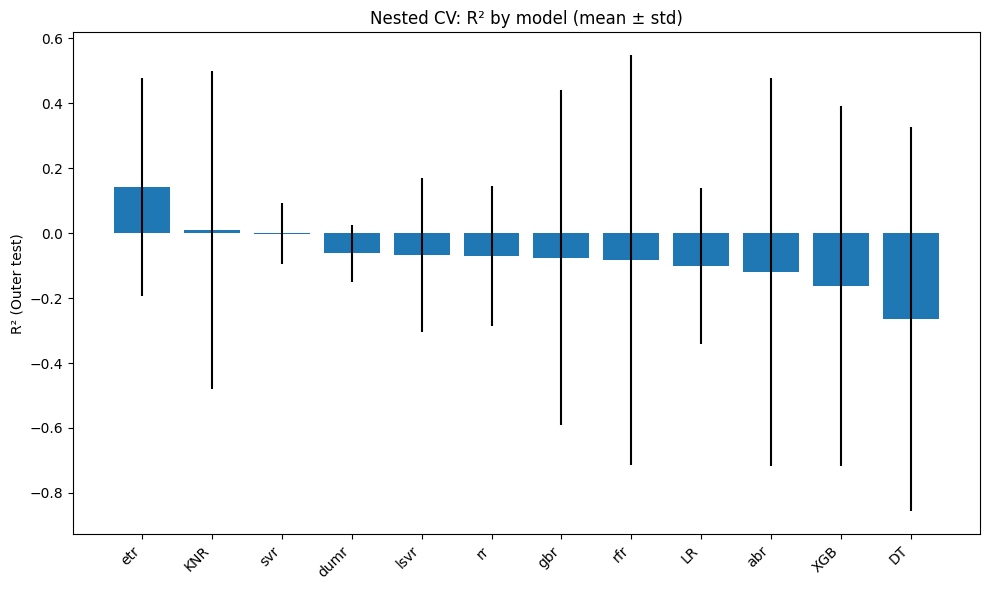

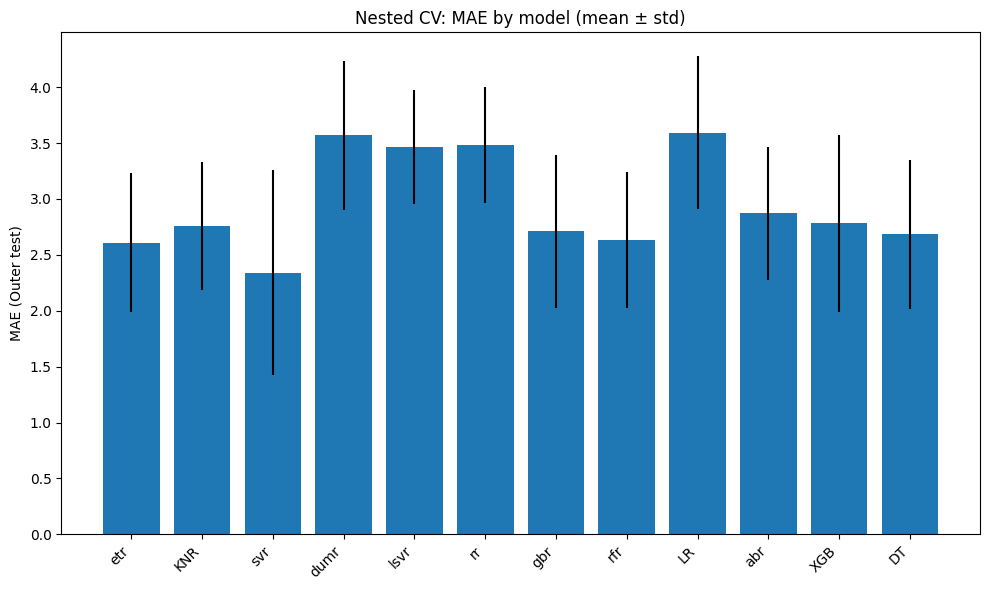

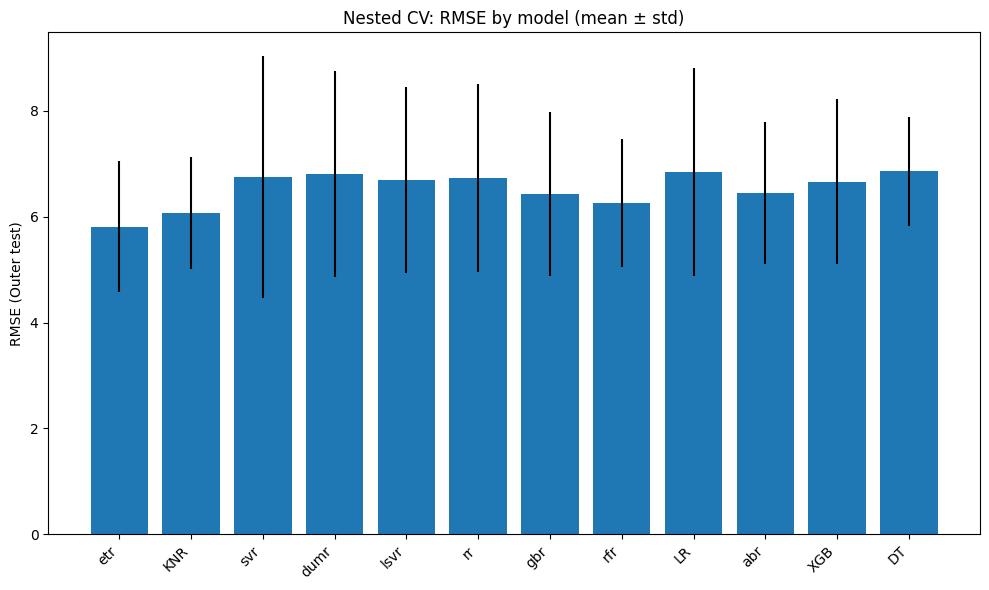

In [6]:
# === Cell 5: Plots using outer-fold metrics (honest estimates) ===
plt.figure(figsize=(10,6))
plt.bar(leaderboard["model_key"], leaderboard["r2_mean"], yerr=leaderboard["r2_std"])
plt.ylabel("R² (Outer test)")
plt.title("Nested CV: R² by model (mean ± std)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig("nestedcv_r2_leaderboard.png", dpi=200)
plt.show()

plt.figure(figsize=(10,6))
plt.bar(leaderboard["model_key"], leaderboard["mae_mean"], yerr=leaderboard["mae_std"])
plt.ylabel("MAE (Outer test)")
plt.title("Nested CV: MAE by model (mean ± std)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig("nestedcv_mae_leaderboard.png", dpi=200)
plt.show()

plt.figure(figsize=(10,6))
plt.bar(leaderboard["model_key"], leaderboard["rmse_mean"], yerr=leaderboard["rmse_std"])
plt.ylabel("RMSE (Outer test)")
plt.title("Nested CV: RMSE by model (mean ± std)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig("nestedcv_rmse_leaderboard.png", dpi=200)
plt.show()


In [7]:
# === Cell 6: Optional — summarize best params frequency across folds ===
import ast

best_param_rows = []
for m, dfm in per_model_folds.items():
    # dfm has a "best_params" column (dict per fold)
    counts = {}
    for params in dfm["best_params"]:
        # ensure dict
        if isinstance(params, str):
            params = ast.literal_eval(params)
        for k, v in params.items():
            counts.setdefault(k, {})
            counts[k][str(v)] = counts[k].get(str(v), 0) + 1
    # flatten counts
    for k, vd in counts.items():
        top = sorted(vd.items(), key=lambda t: t[1], reverse=True)[0]
        best_param_rows.append({"model_key": m, "param": k, "most_common_value": top[0], "freq": top[1]})

best_params_summary = pd.DataFrame(best_param_rows).sort_values(["model_key","freq"], ascending=[True, False])
display(best_params_summary)
best_params_summary.to_csv("nestedcv_best_params_summary.csv", index=False)


,model_key,param,most_common_value,freq
18,DT,model__min_samples_leaf,4,4
19,DT,model__min_samples_split,10,4
17,DT,model__max_depth,4,3
22,KNR,model__weights,uniform,5
21,KNR,model__p,1,4
20,KNR,model__n_neighbors,9,2
31,LR,model__fit_intercept,True,4
35,XGB,model__n_estimators,400,5
32,XGB,model__colsample_bytree,0.7,3
33,XGB,model__learning_rate,0.03,3


In [13]:
# === Cell 7: Helper to collect outer-fold predictions with nested tuning (per model) ===
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd

def _build_base_estimator(key, Est):
    """Mirror Cell 4 defaults for consistency."""
    if key == 'abr':
        return Est(random_state=42)
    elif key in ('rfr', 'etr'):
        return Est(random_state=42, n_jobs=-1)
    elif key in ('gbr', 'DT', 'rr'):
        return Est(random_state=42) if key != 'rr' else Est()
    elif key == 'lsvr':
        return Est(random_state=42)  # max_iter tuned in grid
    elif key in ('svr', 'KNR', 'dumr', 'LR'):
        return Est()
    elif key == 'CBR' and HAS_CAT:
        return Est(random_state=42, verbose=0, allow_writing_files=False)
    elif key == 'XGB' and HAS_XGB:
        return Est(random_state=42, tree_method="hist")
    else:
        return Est()

def collect_oof_predictions(model_key, search="grid", n_iter=50, verbose=0):
    """
    For a given model_key, run a nested CV loop identical to Cell 4 and
    return a DataFrame with columns: ['fold','y_true','y_pred'].
    """
    Est = classic_model_names[model_key]
    if Est is None:
        raise ValueError(f"Library for {model_key} not available.")

    base_est = _build_base_estimator(model_key, Est)
    pipe = Pipeline([("pre", pre), ("model", base_est)])
    grid = param_grids[model_key]  # already prefixed with model__

    # Inner searcher
    if search == "grid":
        SearchCV = GridSearchCV
        search_kwargs = dict(param_grid=grid)
    else:
        SearchCV = RandomizedSearchCV
        search_kwargs = dict(param_distributions=grid, n_iter=n_iter, random_state=42)

    rows = []
    for fold_idx, (tr_idx, te_idx) in enumerate(outer_cv.split(X, y), start=1):
        # keep as pandas (ColumnTransformer uses names)
        X_tr, y_tr = X.iloc[tr_idx], y.iloc[tr_idx]
        X_te, y_te = X.iloc[te_idx], y.iloc[te_idx]

        searcher = SearchCV(
            estimator=pipe,
            cv=inner_cv,
            scoring={"r2": "r2", "neg_mae": "neg_mean_absolute_error", "neg_rmse": "neg_root_mean_squared_error"},
            refit="r2",
            n_jobs=-1,
            verbose=verbose,
            return_train_score=False,
            **search_kwargs,  # ADD THIS LINE - unpacks param_grid or param_distributions
        )
        searcher.fit(X_tr, y_tr)
        best_model = searcher.best_estimator_
        y_pred = best_model.predict(X_te)

        # store each test point as one row (so we can make a single OOF scatter)
        rows.append(pd.DataFrame({
            "fold": fold_idx,
            "y_true": np.asarray(y_te),
            "y_pred": np.asarray(y_pred),
        }))

    oof_df = pd.concat(rows, ignore_index=True)
    # quick diagnostics
    r2 = r2_score(oof_df["y_true"], oof_df["y_pred"])
    mae = mean_absolute_error(oof_df["y_true"], oof_df["y_pred"])
    rmse = mean_squared_error(oof_df["y_true"], oof_df["y_pred"], squared=False)
    print(f"[{model_key}] OOF metrics  R2={r2:.4f}, MAE={mae:.4f}, RMSE={rmse:.4f}")
    return oof_df


/home/ayka89500/miniconda3/envs/gpu121/lib/python3.10/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


[etr] OOF metrics  R2=0.2874, MAE=2.6092, RMSE=5.9410


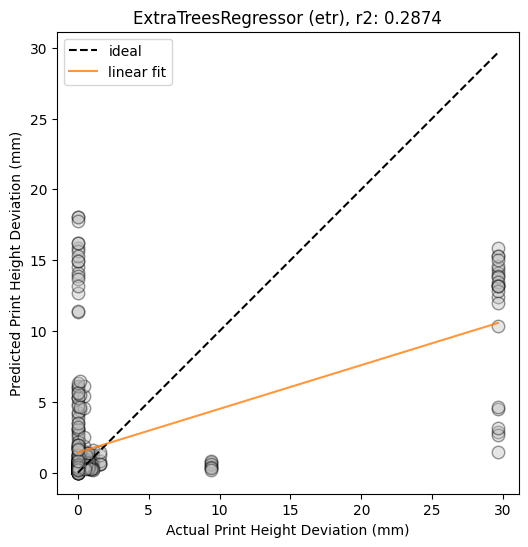

Saved oof_plots/etr_oof_plot.png


/home/ayka89500/miniconda3/envs/gpu121/lib/python3.10/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


[KNR] OOF metrics  R2=0.2324, MAE=2.7567, RMSE=6.1660


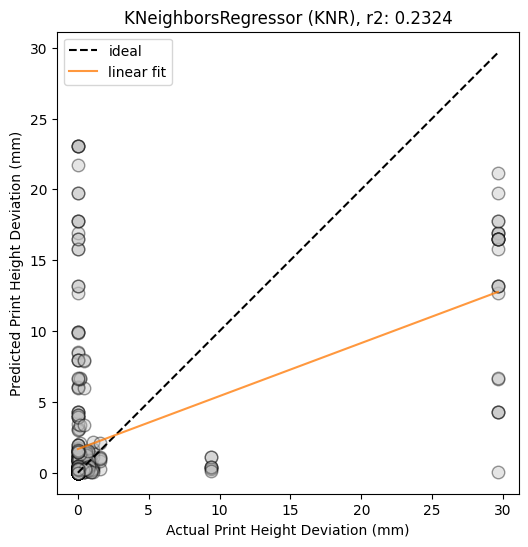

Saved oof_plots/KNR_oof_plot.png


/home/ayka89500/miniconda3/envs/gpu121/lib/python3.10/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


[svr] OOF metrics  R2=-0.0248, MAE=2.3377, RMSE=7.1246


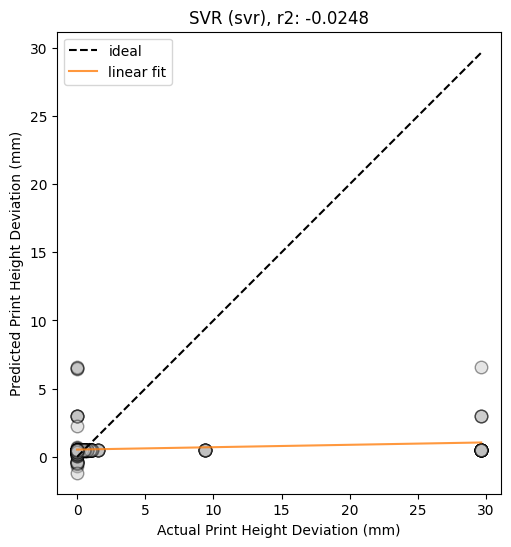

Saved oof_plots/svr_oof_plot.png
[dumr] OOF metrics  R2=-0.0115, MAE=3.5681, RMSE=7.0781


/home/ayka89500/miniconda3/envs/gpu121/lib/python3.10/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


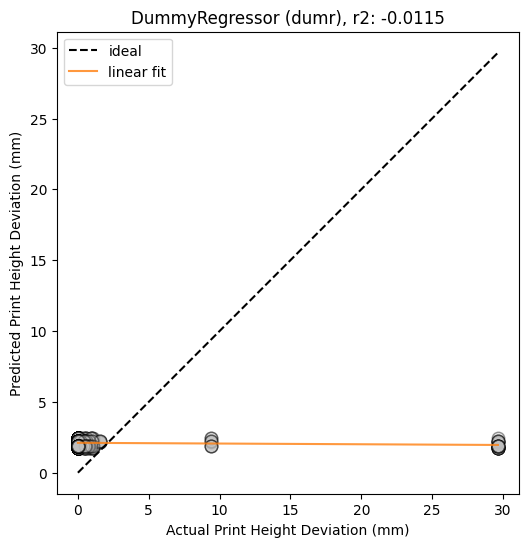

Saved oof_plots/dumr_oof_plot.png


/home/ayka89500/miniconda3/envs/gpu121/lib/python3.10/site-packages/numpy/ma/core.py:2892: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,
/home/ayka89500/miniconda3/envs/gpu121/lib/python3.10/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


[lsvr] OOF metrics  R2=0.0319, MAE=3.4654, RMSE=6.9247


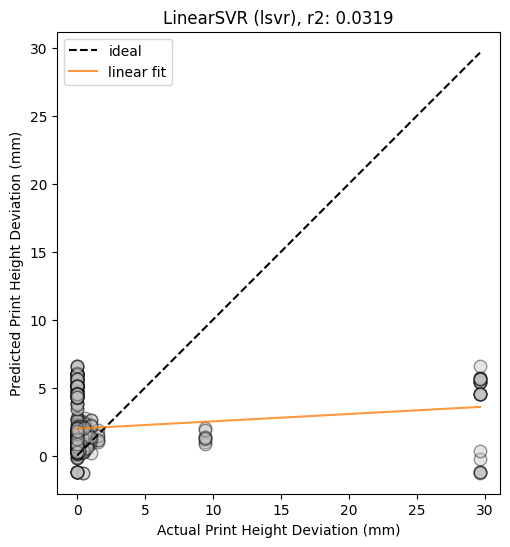

Saved oof_plots/lsvr_oof_plot.png


/home/ayka89500/miniconda3/envs/gpu121/lib/python3.10/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


[rr] OOF metrics  R2=0.0219, MAE=3.4820, RMSE=6.9604


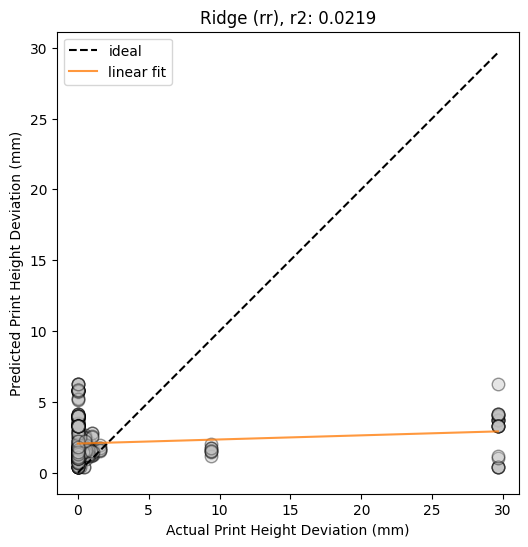

Saved oof_plots/rr_oof_plot.png


/home/ayka89500/miniconda3/envs/gpu121/lib/python3.10/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


[gbr] OOF metrics  R2=0.1154, MAE=2.7092, RMSE=6.6193


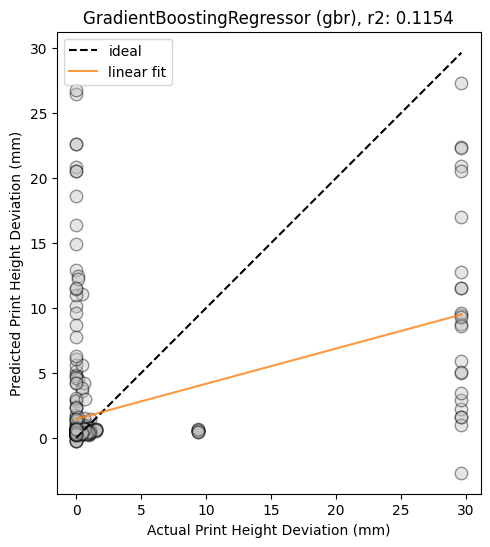

Saved oof_plots/gbr_oof_plot.png


/home/ayka89500/miniconda3/envs/gpu121/lib/python3.10/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


[rfr] OOF metrics  R2=0.1791, MAE=2.6323, RMSE=6.3767


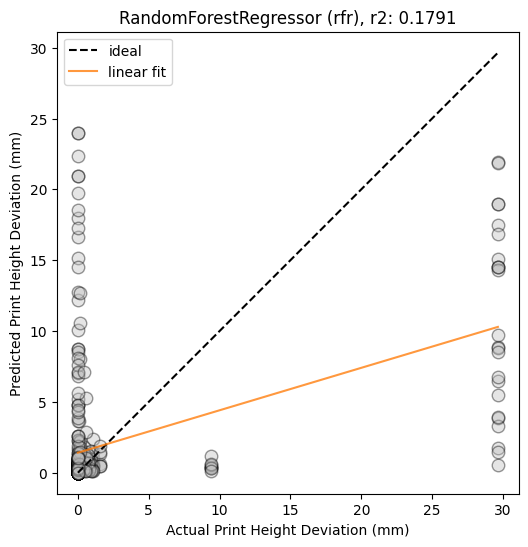

Saved oof_plots/rfr_oof_plot.png
[LR] OOF metrics  R2=-0.0223, MAE=3.5939, RMSE=7.1161


/home/ayka89500/miniconda3/envs/gpu121/lib/python3.10/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


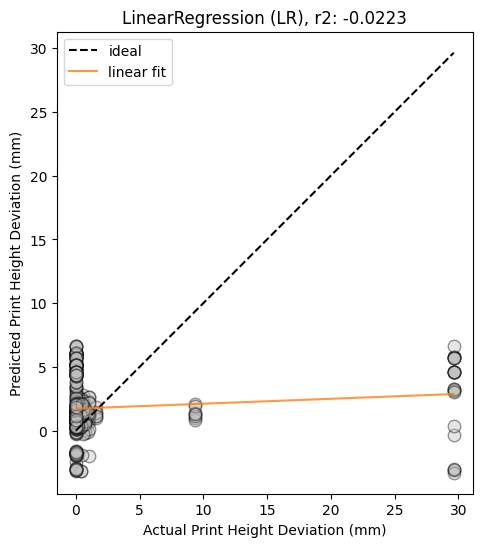

Saved oof_plots/LR_oof_plot.png


/home/ayka89500/miniconda3/envs/gpu121/lib/python3.10/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


[abr] OOF metrics  R2=0.1255, MAE=2.8704, RMSE=6.5816


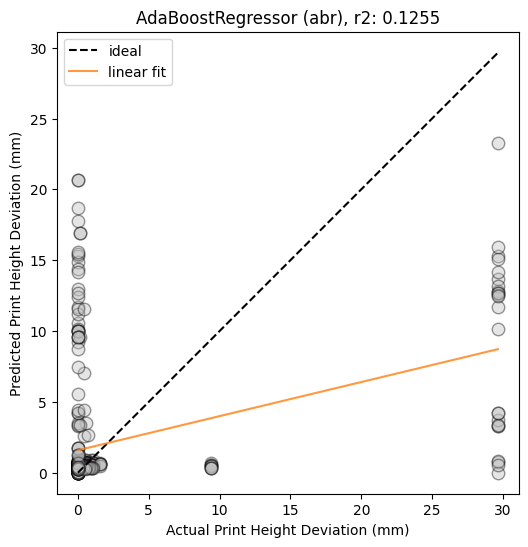

Saved oof_plots/abr_oof_plot.png


/home/ayka89500/miniconda3/envs/gpu121/lib/python3.10/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


[XGB] OOF metrics  R2=0.0562, MAE=2.7811, RMSE=6.8372


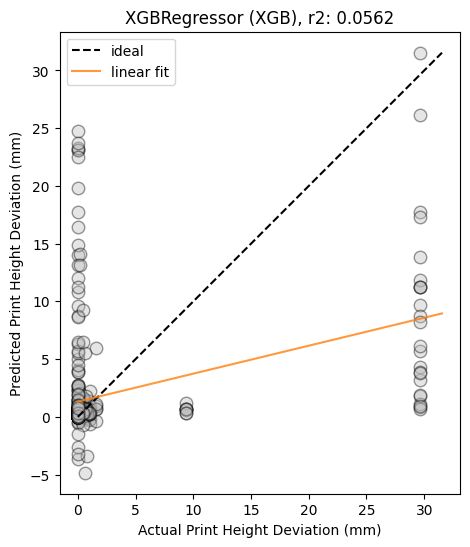

Saved oof_plots/XGB_oof_plot.png


/home/ayka89500/miniconda3/envs/gpu121/lib/python3.10/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


[DT] OOF metrics  R2=0.0298, MAE=2.6824, RMSE=6.9322


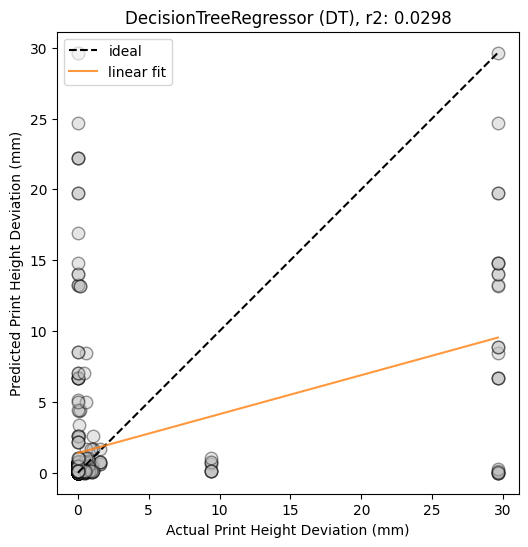

Saved oof_plots/DT_oof_plot.png


In [14]:
# === Cell 8: Plot predicted vs actual using OOF predictions for each model ===
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
import numpy as np
import os

os.makedirs("oof_plots", exist_ok=True)

def plot_pred_act(act, pred, model_label, reg_line=True, xlabel='Actual Print Height Deviation (mm)',
                  ylabel='Predicted Print Height Deviation (mm)'):
    xy_max = np.max([np.max(act), np.max(pred)])
    fig = plt.figure(figsize=(6,6))
    plt.plot(act, pred, 'o', ms=9, mec='k', mfc='silver', alpha=0.4)
    plt.plot([0, xy_max], [0, xy_max], 'k--', label='ideal')
    if reg_line:
        # Use numpy polyfit on the raw arrays
        coeffs = np.polyfit(np.asarray(act), np.asarray(pred), deg=1)
        xs = np.linspace(0, xy_max, 100)
        ys = np.poly1d(coeffs)(xs)
        plt.plot(xs, ys, alpha=0.8, label='linear fit')
    plt.axis('scaled')
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(f'{model_label}, r2: {r2_score(act, pred):0.4f}')
    plt.legend(loc='upper left')
    return fig

# Generate and save a plot for each model in the leaderboard (top to bottom)
for model_key in leaderboard["model_key"]:
    Est = classic_model_names[model_key]
    if Est is None:
        print(f"Skipping {model_key} (library not available).")
        continue

    print(f"Collecting OOF predictions for {model_key} ...")
    oof = collect_oof_predictions(model_key, search="grid", verbose=0)

    # Choose a readable label (pretty name + key)
    pretty = Est.__name__ if hasattr(Est, "__name__") else str(Est)
    label = f"{pretty} ({model_key})"

    fig = plot_pred_act(oof["y_true"], oof["y_pred"], label, reg_line=True)
    out_path = os.path.join("oof_plots", f"{model_key}_oof_plot.png")
    plt.savefig(out_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Saved {out_path}")


In [15]:
# === Cell 9: Final model selection & refit on full data ===
import ast
from collections import Counter
from sklearn.pipeline import Pipeline

# Best model from leaderboard (highest R2, tie-breaker RMSE already applied earlier)
best_key = leaderboard.iloc[0]["model_key"]
print("Best model key:", best_key)

# Find most common best_params across outer folds for the best model
folds_best = per_model_folds[best_key]["best_params"]
# ensure dict
best_params_list = []
for p in folds_best:
    if isinstance(p, str):
        p = ast.literal_eval(p)
    best_params_list.append(p)

# Count each param's most common value
# (We keep only keys that appear in the grid to avoid extraneous fitted params)
grid_keys = set(param_grids[best_key].keys())
param_mode = {}
for k in grid_keys:
    values = [str(d.get(k)) for d in best_params_list if k in d]
    if values:
        most_common_value = Counter(values).most_common(1)[0][0]
        # convert back from str when possible
        try:
            param_mode[k] = ast.literal_eval(most_common_value)
        except Exception:
            param_mode[k] = most_common_value

# Build estimator with those params and fit on full data
Est = classic_model_names[best_key]
final_base = _build_base_estimator(best_key, Est)
final_pipe = Pipeline([("pre", pre), ("model", final_base)])

# Set params on the pipeline (keys already prefixed "model__")
final_pipe.set_params(**param_mode)
final_pipe.fit(X, y)

print("\nFinal refitted pipeline:")
print(final_pipe)

# (Optional) Save the final model with joblib
# from joblib import dump
# dump(final_pipe, f"final_model_{best_key}.joblib")


Best model key: etr

Final refitted pipeline:
Pipeline(steps=[('pre',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler()),
                                                                  ('norm',
                                                                   Normalizer())]),
                                                  ['Speed (mm/s)',
                                                   'Flowrate (Hz)',
                                                   'deposition_ratio'])])),
                ('model',
                 ExtraTreesRegressor(min_samples_leaf=4, min_samples_split=10,
                                     n_estimators=300, n_jobs=-1,
                                     random_state=42))])
